In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from typing import Union, Dict, Tuple
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [43]:
data = pd.read_csv(r'D:\projects\BikeCountPrediction\data\01_raw\train.csv')
data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 0:00:00,1,0,0,1,9.84,14.395,81.0,0.0,3,13,16
1,2011-01-01 1:00:00,1,0,0,1,9.02,13.635,80.0,0.0,8,32,40
2,2011-01-01 2:00:00,1,0,0,1,9.02,13.635,80.0,0.0,5,27,32
3,2011-01-01 3:00:00,1,0,0,1,9.84,14.395,75.0,0.0,3,10,13
4,2011-01-01 4:00:00,1,0,0,1,9.84,14.395,75.0,0.0,0,1,1


In [44]:
data['datetime'] = pd.to_datetime(data['datetime'])

# extract hour
data['hour'] = data['datetime'].dt.hour

# extract weekday (0=Monday, 6=Sunday)
data['weekday'] = data['datetime'].dt.weekday

data.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,weekday
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81.0,0.0,3,13,16,0,5
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80.0,0.0,8,32,40,1,5
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80.0,0.0,5,27,32,2,5
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75.0,0.0,3,10,13,3,5
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75.0,0.0,0,1,1,4,5


In [45]:
data = data.drop(['datetime','casual','registered'],axis=1)

In [46]:
data.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'hour', 'weekday'],
      dtype='str')

In [47]:
def computeMetrics(
    y_true: Union[np.ndarray,list],
    y_pred: Union[np.ndarray,list]
) -> Dict[str,float]:
    y_true = np.array(y_true).ravel()
    y_pred = np.array(y_pred).ravel()
    mae = float(mean_absolute_error(y_true,y_pred))
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true + 1e-8))*100

    return{
        "RMSE": float(round(rmse,2)),
        "MAE": float(round(mae,2)),
        "MAPE": float(round(mape,2))        
    }

In [48]:
def prepareDataset(
    df:pd.DataFrame,
    training_fraction:float = 0.8
) -> Tuple[pd.DataFrame,pd.DataFrame,pd.Series,pd.Series]:
    feats = [col for col in df.columns if col != 'target' ]
    x,y = df[feats],df['target']
    train_size = int(training_fraction * df.shape[0])
    x_train, x_test = x[:train_size],x[train_size:]
    y_train, y_test = y[:train_size],y[train_size:]
    return x_train, x_test, y_train, y_test

## target dataset

In [49]:
df = data.copy()

In [50]:
df['target'] = df['count'].shift(-1).ffill()
df.drop(columns = ['count'],inplace=True)
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,hour,weekday,target
0,1,0,0,1,9.84,14.395,81.0,0.0,0,5,40.0
1,1,0,0,1,9.02,13.635,80.0,0.0,1,5,32.0
2,1,0,0,1,9.02,13.635,80.0,0.0,2,5,13.0
3,1,0,0,1,9.84,14.395,75.0,0.0,3,5,1.0
4,1,0,0,1,9.84,14.395,75.0,0.0,4,5,1.0


## model fitting

In [51]:
x_train,x_test,y_train,y_test = prepareDataset(df,training_fraction=0.8)

In [52]:
params = {
    'learning_rate' : 0.2,
    'depth' : 6,
    'l2_leaf_reg' : 1,
    'iterations' : 500,
    'loss_function' : 'RMSE',
    'verbose' : 0
}

np.random.seed(42)
model = CatBoostRegressor(**params,random_seed = 42) 

model.fit(x_train,y_train)

CatBoostRegressor(depth=6, iterations=500, l2_leaf_reg=1, learning_rate=0.2, loss_function='RMSE', random_seed=42, verbose=0)

## baseline prediction


In [53]:
y_pred = model.predict(x_test)
computeMetrics(y_test,y_pred)

{'RMSE': 125.31, 'MAE': 92.16, 'MAPE': 52.48}

Text(0.5, 1.0, 'Rented Bike Count, 1-h forecast, Baseline')

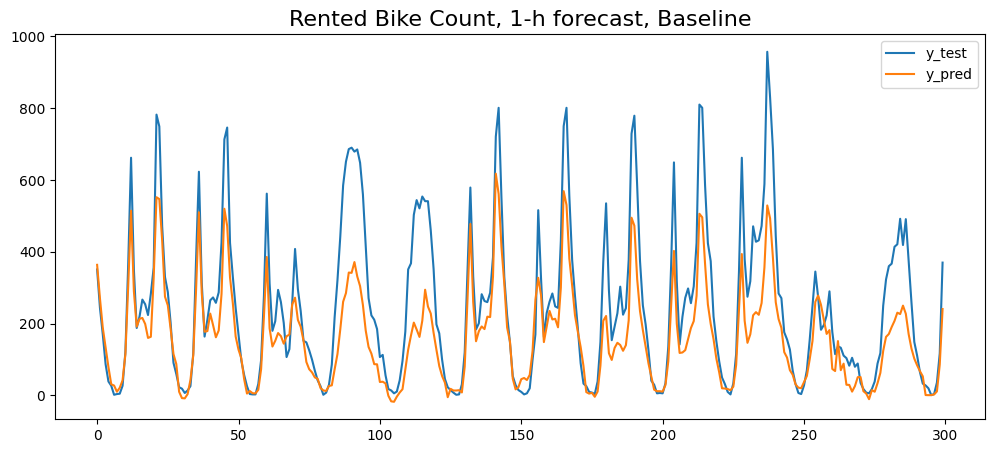

In [54]:
n=300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n],label='y_test')
plt.plot(y_pred[:n],label='y_pred')
plt.legend(fontsize=10)
plt.title('Rented Bike Count, 1-h forecast, Baseline', fontsize = 16)

## baseline with lag

In [55]:
df1 = data.copy()
df1['target'] = df1['count'].shift(-1).ffill()
df1.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,weekday,target
0,1,0,0,1,9.84,14.395,81.0,0.0,16,0,5,40.0
1,1,0,0,1,9.02,13.635,80.0,0.0,40,1,5,32.0
2,1,0,0,1,9.02,13.635,80.0,0.0,32,2,5,13.0
3,1,0,0,1,9.84,14.395,75.0,0.0,13,3,5,1.0
4,1,0,0,1,9.84,14.395,75.0,0.0,1,4,5,1.0


In [56]:
for lag in range(1,25):
    print(f"Lag {lag}: {df['target'].autocorr(lag=lag):.3f}")

Lag 1: 0.844
Lag 2: 0.597
Lag 3: 0.409
Lag 4: 0.277
Lag 5: 0.149
Lag 6: 0.012
Lag 7: -0.094
Lag 8: -0.117
Lag 9: -0.065
Lag 10: -0.060
Lag 11: -0.113
Lag 12: -0.145
Lag 13: -0.117
Lag 14: -0.067
Lag 15: -0.065
Lag 16: -0.099
Lag 17: -0.067
Lag 18: 0.032
Lag 19: 0.152
Lag 20: 0.260
Lag 21: 0.368
Lag 22: 0.516
Lag 23: 0.702
Lag 24: 0.807


In [58]:
# =========================
# STEP 1: Lag features (target)
# =========================
for i in [1,2,3,6,12,24,48,168]:
    df1[f'cnt_lag_{i}'] = df1['count'].shift(i)

# =========================
# STEP 2: Cyclical hour encoding
# =========================
df1['hour_sin'] = np.sin(2 * np.pi * df1['hour'] / 24)
df1['hour_cos'] = np.cos(2 * np.pi * df1['hour'] / 24)


# =========================
# STEP 3: Rolling features and Interaction features
# =========================
df1['rolling_mean_3'] = df1['count'].shift(1).rolling(3).mean()
df1['rolling_mean_6'] = df1['count'].shift(1).rolling(6).mean()
df1['rolling_mean_12'] = df1['count'].shift(1).rolling(12).mean()
df1['rolling_std_6']  = df1['count'].shift(1).rolling(6).std()

df1['diff_1'] = df1['cnt_lag_1'] - df1['cnt_lag_2']
df1['diff_2'] = df1['cnt_lag_2'] - df1['cnt_lag_3']
df1['momentum'] = df1['cnt_lag_1'] / (df1['rolling_mean_3'] + 1e-5)

df1['acceleration'] = df1['diff_1'] - df1['diff_2']
df1['daily_pattern_diff'] = df1['cnt_lag_1'] - df1['cnt_lag_24']
df1['temp_humidity'] = df1['temp'] * df1['humidity']
df1['lag_ratio'] = df1['cnt_lag_1'] / (df1['cnt_lag_24'] + 1e-5)

# =========================
# STEP 4: Drop NA rows
# =========================
df1 = df1.dropna()

In [59]:
df1.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'count', 'hour', 'weekday', 'target',
       'cnt_lag_1', 'cnt_lag_2', 'cnt_lag_3', 'cnt_lag_6', 'cnt_lag_12',
       'cnt_lag_24', 'cnt_lag_48', 'cnt_lag_168', 'hour_sin', 'hour_cos',
       'rolling_mean_3', 'rolling_mean_6', 'rolling_mean_12', 'rolling_std_6',
       'diff_1', 'diff_2', 'momentum', 'acceleration', 'daily_pattern_diff',
       'temp_humidity', 'lag_ratio'],
      dtype='str')

In [60]:
df1.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,...,rolling_mean_6,rolling_mean_12,rolling_std_6,diff_1,diff_2,momentum,acceleration,daily_pattern_diff,temp_humidity,lag_ratio
168,1,0,0,2,6.56,9.09,74.0,7.0015,9,7,...,7.833333,25.666667,6.675827,-3.0,4.0,0.749997,-7.0,-82.0,485.44,0.023810
169,1,0,0,3,6.56,9.09,93.0,7.0015,15,8,...,6.666667,18.500000,5.465040,7.0,-3.0,1.687497,10.0,-201.0,610.08,0.042857
170,1,0,0,3,6.56,9.09,93.0,7.0015,20,9,...,6.500000,15.500000,5.128353,6.0,7.0,1.730767,-1.0,-119.0,610.08,0.111940
171,1,0,0,2,7.38,9.85,80.0,11.0014,61,10,...,8.666667,13.916667,7.554248,5.0,6.0,1.363635,-1.0,-43.0,590.40,0.317460
172,1,0,0,2,8.20,9.09,69.0,26.0027,62,11,...,18.666667,16.000000,21.750096,41.0,5.0,1.906249,36.0,-6.0,565.80,0.910448


In [61]:
x_train,x_test,y_train,y_test = prepareDataset(df1,training_fraction=0.8)

In [62]:
x_train.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,count,hour,...,rolling_mean_6,rolling_mean_12,rolling_std_6,diff_1,diff_2,momentum,acceleration,daily_pattern_diff,temp_humidity,lag_ratio
168,1,0,0,2,6.56,9.09,74.0,7.0015,9,7,...,7.833333,25.666667,6.675827,-3.0,4.0,0.749997,-7.0,-82.0,485.44,0.023810
169,1,0,0,3,6.56,9.09,93.0,7.0015,15,8,...,6.666667,18.500000,5.465040,7.0,-3.0,1.687497,10.0,-201.0,610.08,0.042857
170,1,0,0,3,6.56,9.09,93.0,7.0015,20,9,...,6.500000,15.500000,5.128353,6.0,7.0,1.730767,-1.0,-119.0,610.08,0.111940
171,1,0,0,2,7.38,9.85,80.0,11.0014,61,10,...,8.666667,13.916667,7.554248,5.0,6.0,1.363635,-1.0,-43.0,590.40,0.317460
172,1,0,0,2,8.20,9.09,69.0,26.0027,62,11,...,18.666667,16.000000,21.750096,41.0,5.0,1.906249,36.0,-6.0,565.80,0.910448


In [63]:
df1.drop(columns=['count'],inplace=True)

## retraining with lag using CatBoost

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor

param_dist = {
    'depth': [6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'iterations': [500, 800, 1000],
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bylevel': [0.7, 0.8, 1.0]
}

weights = 1 + (y_train / y_train.mean())**2

In [67]:
from sklearn.model_selection import ParameterSampler
from tqdm import tqdm
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

# =========================
# Generate random param combinations
# =========================
param_list = list(ParameterSampler(param_dist, n_iter=20, random_state=42))

best_score = float('inf')
best_params = None
best_model = None

results = []

# =========================
# Tuning loop with progress bar
# =========================
for params in tqdm(param_list, desc="Hyperparameter Tuning"):

    model = CatBoostRegressor(
        **params,
        loss_function='Quantile:alpha=0.7',  # 🔥 better for peaks
        eval_metric='MAPE',
        random_seed=42,
        verbose=0
    )

    model.fit(
        x_train, y_train,
        sample_weight=weights,
        eval_set=(x_test, y_test),
        early_stopping_rounds=50,
        verbose=False
    )

    # Predict
    y_pred = model.predict(x_test)

    # Evaluate
    score = mean_absolute_error(y_test, y_pred)

    results.append((params, score))

    # Track best
    if score < best_score:
        best_score = score
        best_params = params
        best_model = model
        print(f"\nNew Best MAE: {best_score:.2f}")
        print(f"Params: {best_params}")

# =========================
# Final Output
# =========================
print("\n=========================")
print("Best Score (MAE):", best_score)
print("Best Params:", best_params)

Hyperparameter Tuning:   5%|████▌                                                                                      | 1/20 [00:12<03:58, 12.55s/it]


New Best MAE: 60.86
Params: {'subsample': 1.0, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 8, 'colsample_bylevel': 1.0}


Hyperparameter Tuning:  10%|█████████                                                                                  | 2/20 [00:22<03:22, 11.25s/it]


New Best MAE: 50.32
Params: {'subsample': 0.8, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 800, 'depth': 6, 'colsample_bylevel': 0.7}


Hyperparameter Tuning: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 20/20 [12:31<00:00, 37.56s/it]


Best Score (MAE): 50.31966113800106
Best Params: {'subsample': 0.8, 'learning_rate': 0.05, 'l2_leaf_reg': 7, 'iterations': 800, 'depth': 6, 'colsample_bylevel': 0.7}


In [87]:
final_model_cb = best_model

# predictions
y_pred_cat = final_model_cb.predict(x_test)
computeMetrics(y_test,y_pred)

{'RMSE': 79.42, 'MAE': 50.39, 'MAPE': 33.74}

Text(0.5, 1.0, 'Rented Bike Count, 1-h forecast, Catboost')

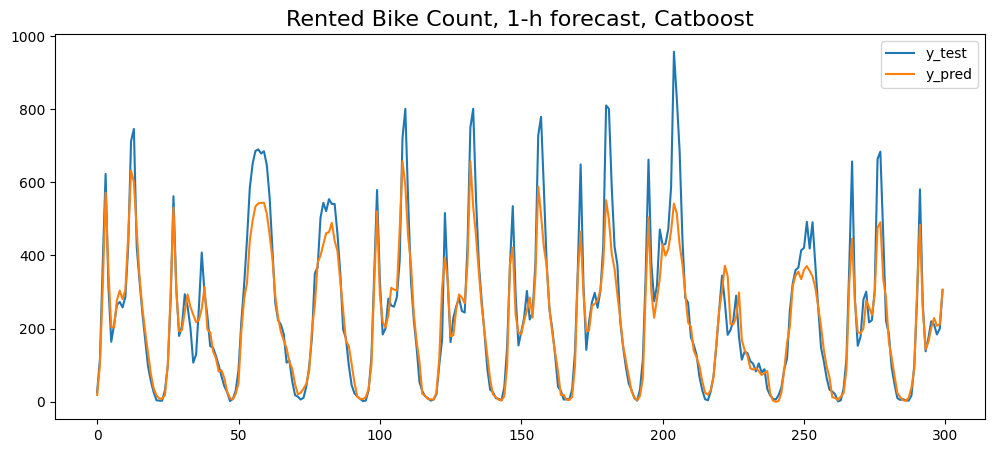

In [69]:
n=300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n],label='y_test')
plt.plot(y_pred_cat[:n],label='y_pred')
plt.legend(fontsize=10)
plt.title('Rented Bike Count, 1-h forecast, Catboost', fontsize = 16)

In [73]:
final_model_cb.save_model('../data/06_models/catboost_model.cbm')

## retraining using xgboost

In [74]:
from xgboost import XGBRegressor

# =========================
# Parameter space
# =========================
param_dist = {
    'max_depth': [6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [500, 800, 1000],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3],
    'reg_lambda': [1, 3, 5]
}

param_list = list(ParameterSampler(param_dist, n_iter=20, random_state=42))

best_score = float('inf')
best_params = None
best_model = None

# =========================
# Tuning loop
# =========================
for params in tqdm(param_list, desc="XGBoost Tuning"):

    model = XGBRegressor(
        **params,
        objective='reg:pseudohubererror',  # 🔥 robust for peaks
        random_state=42,
        n_jobs=-1,
        early_stopping_rounds=50 
    )

    model.fit(
        x_train, y_train,
        sample_weight=weights,
        eval_set=[(x_test, y_test)],
        verbose=False
    )

    y_pred = model.predict(x_test)

    score = mean_absolute_error(y_test, y_pred)

    # Track best
    if score < best_score:
        best_score = score
        best_params = params
        best_model = model

        print(f"\n🔥 New Best MAE: {best_score:.2f}")
        print(f"Params: {best_params}")

# =========================
# Final results
# =========================
print("\n=======================")
print("Best MAE:", best_score)
print("Best Params:", best_params)


XGBoost Tuning:   5%|████▉                                                                                             | 1/20 [00:11<03:31, 11.12s/it]


🔥 New Best MAE: 49.56
Params: {'subsample': 1.0, 'reg_lambda': 3, 'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}


XGBoost Tuning:  15%|██████████████▋                                                                                   | 3/20 [00:41<04:05, 14.42s/it]


🔥 New Best MAE: 48.40
Params: {'subsample': 1.0, 'reg_lambda': 3, 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.8}


XGBoost Tuning: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [03:01<00:00,  9.08s/it]


Best MAE: 48.400338333422575
Best Params: {'subsample': 1.0, 'reg_lambda': 3, 'n_estimators': 1000, 'max_depth': 10, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.8}


In [88]:
final_model_xg = best_model

# predictions
y_pred_xg = final_model_xg.predict(x_test)
computeMetrics(y_test,y_pred)

{'RMSE': 79.42, 'MAE': 50.39, 'MAPE': 33.74}

Text(0.5, 1.0, 'Rented Bike Count, 1-h forecast, XGBoost')

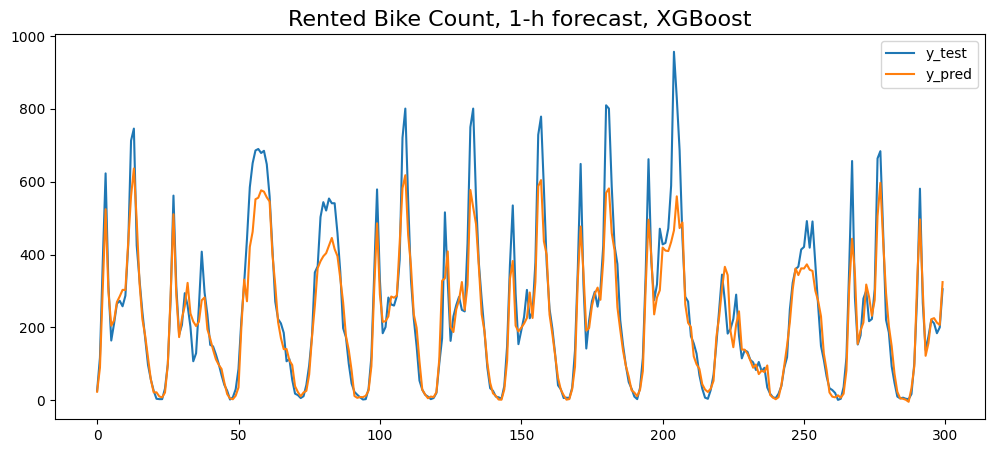

In [76]:
n=300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n],label='y_test')
plt.plot(y_pred_xg[:n],label='y_pred')
plt.legend(fontsize=10)
plt.title('Rented Bike Count, 1-h forecast, XGBoost', fontsize = 16)

In [77]:
final_model_xg.save_model("../data/06_models/xgb_model.json")

## retraining with LightGBM

In [78]:
from lightgbm import LGBMRegressor

# =========================
# Param space
# =========================
param_dist_lgb = {
    'num_leaves': [32, 64, 128],
    'learning_rate': [0.01, 0.03, 0.05],
    'n_estimators': [500, 800, 1200],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

param_list = list(ParameterSampler(param_dist_lgb, n_iter=20, random_state=42))

best_score = float('inf')
best_params = None
best_model = None

# =========================
# Tuning loop
# =========================
for params in tqdm(param_list, desc="LightGBM Tuning"):

    model = LGBMRegressor(
        **params,
        random_state=42
    )

    model.fit(
        x_train, y_train,
        sample_weight=weights,
        eval_set=[(x_test, y_test)],
        eval_metric='l1'
    )

    y_pred = model.predict(x_test)
    score = mean_absolute_error(y_test, y_pred)

    if score < best_score:
        best_score = score
        best_params = params
        best_model = model

        print(f"\n🔥 New Best MAE: {best_score:.2f}")
        print(f"Params: {best_params}")

print("\n===== LightGBM BEST =====")
print(best_params)

LightGBM Tuning:   0%|                                                                                                         | 0/20 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003581 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 279.388478


LightGBM Tuning:   5%|████▊                                                                                            | 1/20 [00:15<04:55, 15.57s/it]


🔥 New Best MAE: 50.06
Params: {'subsample': 0.7, 'num_leaves': 128, 'n_estimators': 1200, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004407 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 279.388478


LightGBM Tuning:  10%|█████████▋                                                                                       | 2/20 [00:23<03:24, 11.36s/it]

...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002028 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 279.388478


LightGBM Tuning:  95%|███████████████████████████████████████████████████████████████████████████████████████████▏    | 19/20 [02:23<00:07,  7.51s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002746 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 279.388478


LightGBM Tuning: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [02:27<00:00,  7.37s/it]


===== LightGBM BEST =====
{'subsample': 1.0, 'num_leaves': 128, 'n_estimators': 800, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [89]:
final_model_lgb = best_model

# predictions
y_pred_lgb = final_model_lgb.predict(x_test)
computeMetrics(y_test, y_pred_lgb)

{'RMSE': 78.94, 'MAE': 49.31, 'MAPE': 29.2}

Text(0.5, 1.0, 'Rented Bike Count, 1-h forecast, LightGBM')

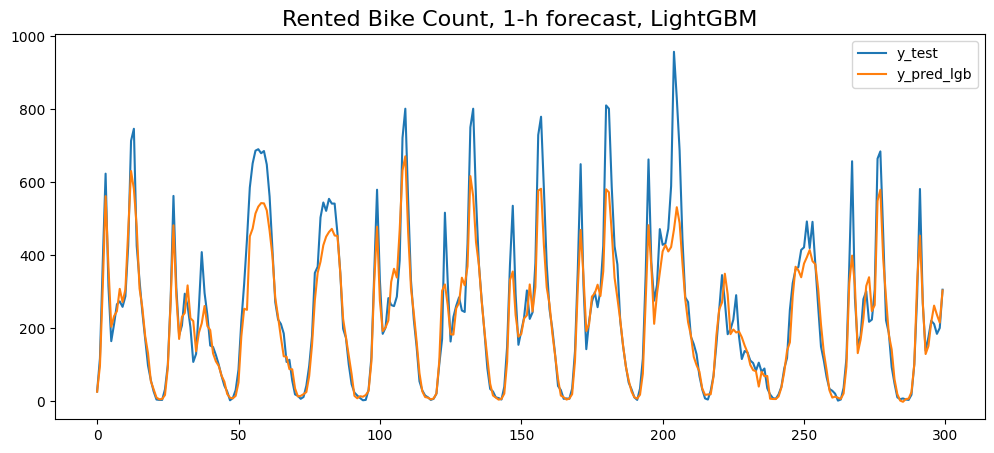

In [80]:
n=300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n],label='y_test')
plt.plot(y_pred_lgb[:n],label='y_pred_lgb')
plt.legend(fontsize=10)
plt.title('Rented Bike Count, 1-h forecast, LightGBM', fontsize = 16)

In [81]:
final_model_lgb.booster_.save_model("../data/06_models/lightgbm_model.txt")

## retraining with hybrid residual method

### base model

In [82]:
param_list = list(ParameterSampler(param_dist_lgb, n_iter=10, random_state=42))

best_base = None
best_base_score = float('inf')

for params in tqdm(param_list, desc="Base Model Tuning"):

    model = LGBMRegressor(**params, random_state=42)
    model.fit(x_train, y_train)

    pred = model.predict(x_train)
    score = mean_absolute_error(y_train, pred)

    if score < best_base_score:
        best_base_score = score
        best_base = model

Base Model Tuning:   0%|                                                                                                       | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003566 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 146.153576


Base Model Tuning:  10%|█████████▌                                                                                     | 1/10 [00:11<01:42, 11.43s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002811 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 146.153576


Base Model Tuning:  20%|███████████████████                                                                            | 2/10 [00:16<00:59,  7.47s/it]

...

Base Model Tuning:  80%|████████████████████████████████████████████████████████████████████████████                   | 8/10 [01:06<00:16,  8.46s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002319 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 146.153576


Base Model Tuning:  90%|█████████████████████████████████████████████████████████████████████████████████████▌         | 9/10 [01:08<00:06,  6.69s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002256 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score 146.153576


Base Model Tuning: 100%|██████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:11<00:00,  7.18s/it]


In [83]:
y_train_pred = best_base.predict(x_train)
y_test_pred = best_base.predict(x_test)

residual_train = y_train - y_train_pred

In [84]:
best_res_model = None
best_res_score = float('inf')

param_list_res = list(ParameterSampler(param_dist_lgb, n_iter=10, random_state=42))

for params in tqdm(param_list_res, desc="Residual Model Tuning"):

    model = LGBMRegressor(**params, random_state=42)
    model.fit(x_train, residual_train)

    res_pred = model.predict(x_train)
    score = mean_absolute_error(residual_train, res_pred)

    if score < best_res_score:
        best_res_score = score
        best_res_model = model

Residual Model Tuning:   0%|                                                                                                   | 0/10 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score -0.000000


Residual Model Tuning:  10%|█████████                                                                                  | 1/10 [00:10<01:32, 10.24s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001799 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score -0.000000


Residual Model Tuning:  20%|██████████████████▏                                                                        | 2/10 [00:14<00:53,  6.68s/it]

...

Residual Model Tuning:  80%|████████████████████████████████████████████████████████████████████████▊                  | 8/10 [01:01<00:16,  8.13s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002203 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score -0.000000


Residual Model Tuning:  90%|█████████████████████████████████████████████████████████████████████████████████▉         | 9/10 [01:04<00:06,  6.30s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002617 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5398
[LightGBM] [Info] Number of data points in the train set: 10249, number of used features: 32
[LightGBM] [Info] Start training from score -0.000000


Residual Model Tuning: 100%|██████████████████████████████████████████████████████████████████████████████████████████| 10/10 [01:06<00:00,  6.65s/it]


In [85]:
residual_pred = best_res_model.predict(x_test)

y_final = y_test_pred + residual_pred

print("\n===== HYBRID RESULTS =====")
computeMetrics(y_test, y_final)


===== HYBRID RESULTS =====


{'RMSE': 85.52, 'MAE': 52.57, 'MAPE': 29.73}

Text(0.5, 1.0, 'Rented Bike Count, 1-h forecast, Hybrid residual')

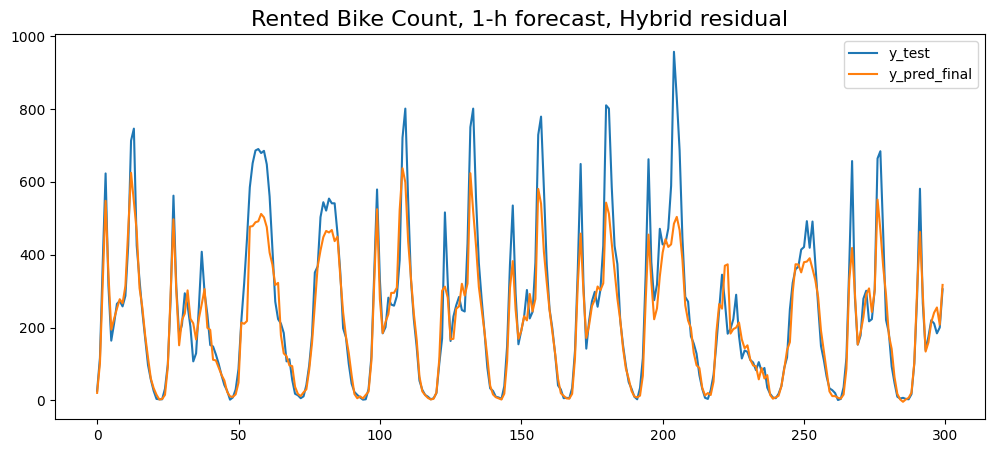

In [86]:
n=300
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:n],label='y_test')
plt.plot(y_final[:n],label='y_pred_final')
plt.legend(fontsize=10)
plt.title('Rented Bike Count, 1-h forecast, Hybrid residual', fontsize = 16)

In [91]:
y_pred = (
    0.5 * y_pred_xg +
    0.3 * y_pred_lgb +
    0.2 * y_pred_cat
)

In [94]:
computeMetrics(y_test, y_pred)

{'RMSE': 78.94, 'MAE': 49.31, 'MAPE': 29.2}